<a href="https://colab.research.google.com/github/chetankodigantiML/ECGR4105-F26/blob/main/HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import scipy as stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate, KFold
from sklearn.svm import SVC
from sklearn.decomposition import PCA as RandomizedPCA
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# PROBLEM 1

In [ ]:
cancer_data = pd.read_csv('/content/drive/MyDrive/Fall26/ECGR4105/HW4/Cancer.csv')
cancer_data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
cancer_colm = ['radius_mean',	'texture_mean',	'perimeter_mean',	'area_mean',	'smoothness_mean',	'compactness_mean',	'concavity_mean',	'concave points_mean',	'symmetry_mean',	'fractal_dimension_mean',	'radius_se',	'texture_se',	'perimeter_se',	'area_se',	'smoothness_se'	,'compactness_se',	'concavity_se',	'concave points_se'	,'symmetry_se',	'fractal_dimension_se'	,'radius_worst',	'texture_worst',	'perimeter_worst',	'area_worst',	'smoothness_worst',	'compactness_worst',	'concavity_worst'	,'concave points_worst'	,'symmetry_worst'	,'fractal_dimension_worst']

scaler = MinMaxScaler()
cancer_data[cancer_colm] = scaler.fit_transform(cancer_data[cancer_colm])

c_train, c_test = train_test_split(cancer_data, train_size=0.8, test_size=0.2, random_state=42)

c_tr_y = c_train['diagnosis']
c_tr_x = c_train[cancer_colm]

c_tst_y = c_test['diagnosis']
c_tst_x = c_test[cancer_colm]

In [ ]:
def svc_type(kernel_type, fold_num):
  pca = RandomizedPCA(n_components=len(c_tr_x.columns), whiten=True, random_state=42)
  svc = SVC(kernel=kernel_type, class_weight='balanced', degree=1)
  model = make_pipeline(pca,svc)
  param_grid = {'svc__C': [1, 5, 10, 50], 'svc__gamma' : [0.0001, 0.0005, 0.001, 0.005]}
  grid = GridSearchCV(model, param_grid)
  %time grid.fit(c_tr_x, c_tr_y)
  model = grid.best_estimator_
  yfit = model.predict(c_tst_x)

  scoring = {'accuracy': 'accuracy', 'precision': 'precision_macro','recall': 'recall_macro'}

  kfold = KFold(n_splits=fold_num, shuffle=True, random_state=42)

  results = cross_validate(model, c_tr_x, c_tr_y, cv=kfold, scoring=scoring, return_train_score=False)
  return results, yfit


In [ ]:
kernel_type = ['linear', 'poly', 'rbf', 'sigmoid']

lin_results, lin_yfit = svc_type(kernel_type[0], 8)
poly_results, poly_yfit = svc_type(kernel_type[1], 10)
rbf_results, rbf_yfit = svc_type(kernel_type[2], 10)
sig_results, sig_yfit = svc_type(kernel_type[3], 10)

CPU times: user 1.83 s, sys: 4.95 ms, total: 1.84 s
Wall time: 1.89 s
CPU times: user 2.22 s, sys: 3.1 ms, total: 2.22 s
Wall time: 4.91 s
CPU times: user 2.28 s, sys: 6.47 ms, total: 2.29 s
Wall time: 3.61 s
CPU times: user 2.57 s, sys: 4.38 ms, total: 2.58 s
Wall time: 4.08 s


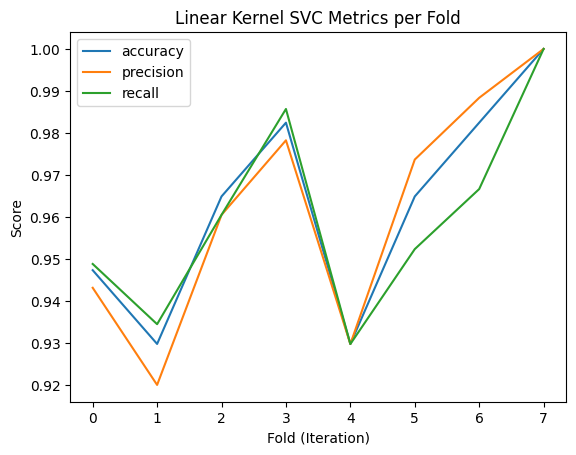

              precision    recall  f1-score   support

           B       0.96      0.97      0.97        71
           M       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



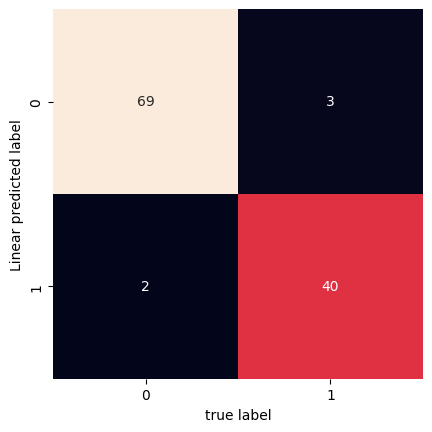

In [ ]:
plt.plot(lin_results['test_accuracy'], label='accuracy')
plt.plot(lin_results['test_precision'], label='precision')
plt.plot(lin_results['test_recall'], label='recall')
plt.xlabel('Fold (Iteration)')
plt.ylabel('Score')
plt.title('Linear Kernel SVC Metrics per Fold')
plt.legend()
plt.show()

print(classification_report(c_tst_y, lin_yfit))
lin_mat = confusion_matrix(c_tst_y, lin_yfit)
sns.heatmap(lin_mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.ylabel('Linear predicted label');

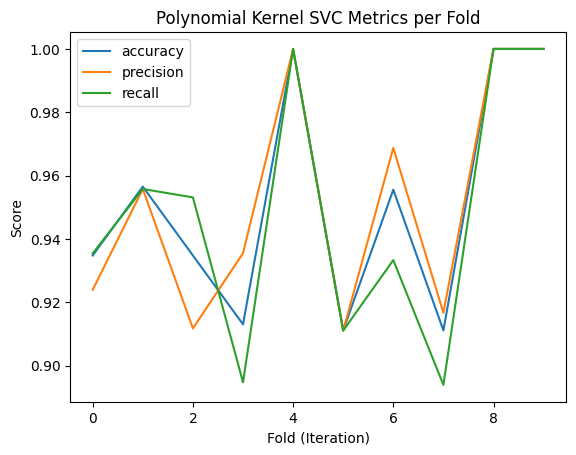

              precision    recall  f1-score   support

           B       0.94      0.93      0.94        71
           M       0.89      0.91      0.90        43

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



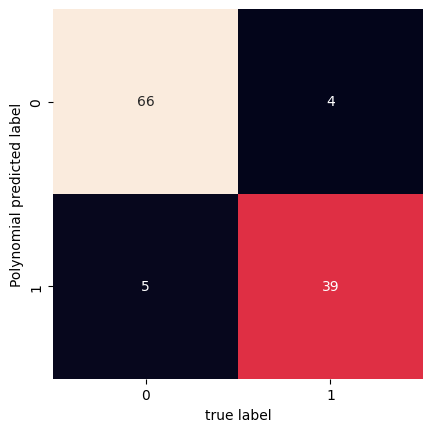

In [ ]:
plt.plot(poly_results['test_accuracy'], label='accuracy')
plt.plot(poly_results['test_precision'], label='precision')
plt.plot(poly_results['test_recall'], label='recall')
plt.xlabel('Fold (Iteration)')
plt.ylabel('Score')
plt.title('Polynomial Kernel SVC Metrics per Fold')
plt.legend()
plt.show()

print(classification_report(c_tst_y, poly_yfit))
poly_mat = confusion_matrix(c_tst_y, poly_yfit)
sns.heatmap(poly_mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.ylabel('Polynomial predicted label');

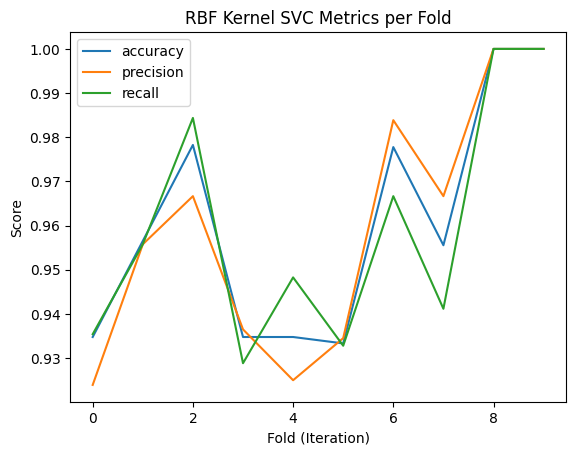

              precision    recall  f1-score   support

           B       0.96      0.94      0.95        71
           M       0.91      0.93      0.92        43

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



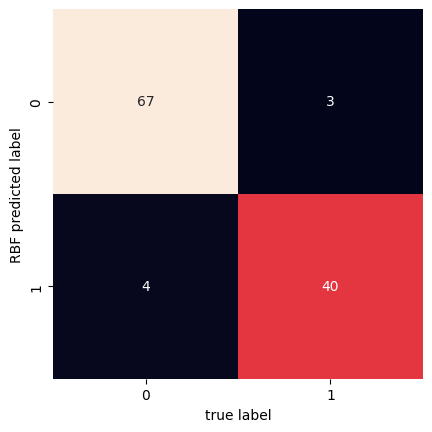

In [ ]:
plt.plot(rbf_results['test_accuracy'], label='accuracy')
plt.plot(rbf_results['test_precision'], label='precision')
plt.plot(rbf_results['test_recall'], label='recall')
plt.xlabel('Fold (Iteration)')
plt.ylabel('Score')
plt.title('RBF Kernel SVC Metrics per Fold')
plt.legend()
plt.show()

print(classification_report(c_tst_y, rbf_yfit))
rbf_mat = confusion_matrix(c_tst_y, rbf_yfit)
sns.heatmap(rbf_mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.ylabel('RBF predicted label');

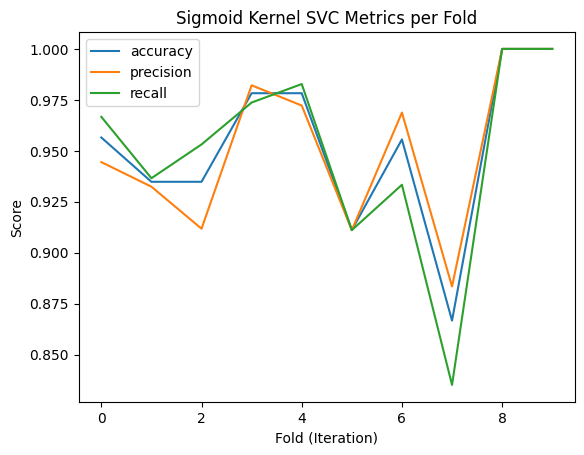

              precision    recall  f1-score   support

           B       0.96      0.94      0.95        71
           M       0.91      0.93      0.92        43

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



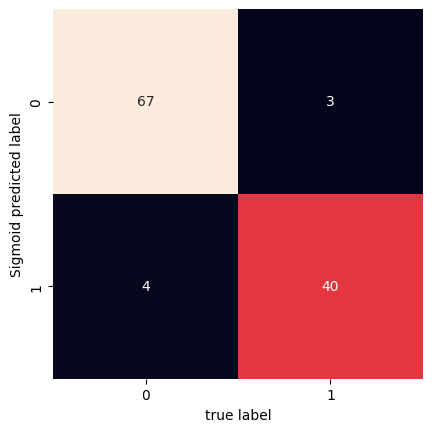

In [ ]:
plt.plot(sig_results['test_accuracy'], label='accuracy')
plt.plot(sig_results['test_precision'], label='precision')
plt.plot(sig_results['test_recall'], label='recall')
plt.xlabel('Fold (Iteration)')
plt.ylabel('Score')
plt.title('Sigmoid Kernel SVC Metrics per Fold')
plt.legend()
plt.show()

print(classification_report(c_tst_y, sig_yfit))
sig_mat = confusion_matrix(c_tst_y, sig_yfit)
sns.heatmap(sig_mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.ylabel('Sigmoid predicted label');

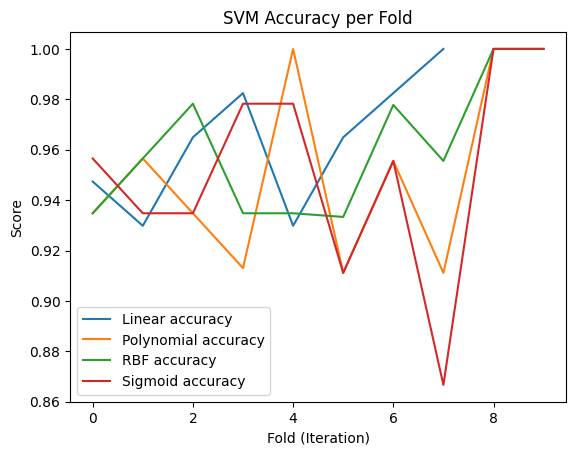

In [ ]:
plt.plot(lin_results['test_accuracy'], label='Linear accuracy')
plt.plot(poly_results['test_accuracy'], label='Polynomial accuracy')
plt.plot(rbf_results['test_accuracy'], label='RBF accuracy')
plt.plot(sig_results['test_accuracy'], label='Sigmoid accuracy')
plt.xlabel('Fold (Iteration)')
plt.ylabel('Score')
plt.title('SVM Accuracy per Fold')
plt.legend()
plt.show()

# PROBLEM 2

In [ ]:
housing_data = pd.read_csv('/content/drive/MyDrive/Fall26/ECGR4105/HW4/Housing.csv')
housing_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
binary_dict = {'yes': 1, 'no': 0}
furnish_dict = {'furnished': 1, 'semi-furnished': 0.5, 'unfurnished': 0}

housing_data['mainroad'] = housing_data['mainroad'].map(binary_dict)
housing_data['guestroom'] = housing_data['guestroom'].map(binary_dict)
housing_data['basement'] = housing_data['basement'].map(binary_dict)
housing_data['hotwaterheating']  = housing_data['hotwaterheating'].map(binary_dict)
housing_data['airconditioning']  = housing_data['airconditioning'].map(binary_dict)
housing_data['prefarea'] = housing_data['prefarea'].map(binary_dict)
housing_data['furnishingstatus'] = housing_data['furnishingstatus'].map(furnish_dict)

housing_colm = ['area',	'bedrooms',	'bathrooms',	'stories', 'parking',]
house_colm = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
scaler = StandardScaler()
housing_data[housing_colm] = scaler.fit_transform(housing_data[housing_colm])

h_train, h_test = train_test_split(housing_data, train_size=0.8, test_size=0.2, random_state=42)

h_tr_y = h_train['price']
h_tr_x = h_train[house_colm]

h_tst_y = h_test['price']
h_tst_x = h_test[house_colm]

h_train

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,7525000,0.391790,0.047278,1.421812,2.532024,1,0,0,0,1,0.355976,0,1.0
93,6300000,0.945257,0.047278,1.421812,-0.929397,1,0,1,0,1,2.679409,0,0.5
335,3920000,-0.615521,-1.308863,-0.570187,-0.929397,1,0,1,0,1,1.517692,0,1.0
412,3430000,-1.171756,0.047278,-0.570187,0.224410,1,0,1,0,0,-0.805741,1,0.0
471,3010000,-0.645962,0.047278,-0.570187,0.224410,1,0,0,0,0,-0.805741,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,6755000,0.391790,1.403419,1.421812,2.532024,1,0,0,0,1,-0.805741,0,0.0
106,6160000,0.138117,1.403419,1.421812,-0.929397,1,0,1,0,1,-0.805741,1,0.5
270,4340000,-0.300045,0.047278,1.421812,1.378217,1,0,0,1,0,0.355976,0,1.0
435,3290000,-0.512207,-1.308863,-0.570187,-0.929397,1,0,0,0,0,-0.805741,0,0.0


In [87]:
from sklearn.svm import SVR

def svr_type(kernel_type):
  svr = SVR(kernel=kernel_type, C=1000, gamma=10, degree=2)
  y_test = svr.fit(h_tr_x, h_tr_y).predict(h_tst_x)
  return svr, y_test



svr_lin, lin_y_pred = svr_type('linear')
svr_poly, poly_y_pred = svr_type('poly')
svr_rbf, rbf_y_pred = svr_type('rbf')
svr_sig, sig_y_pred = svr_type('sigmoid')

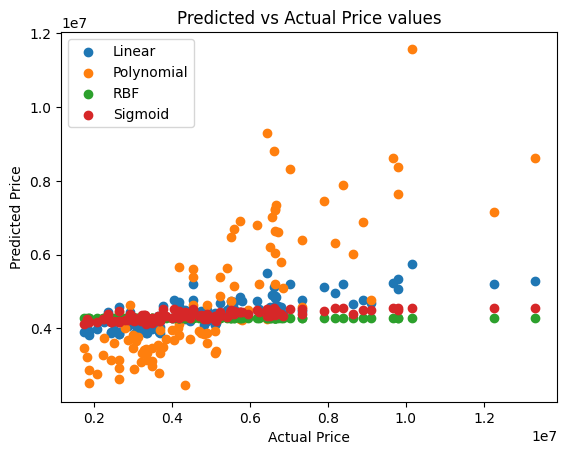

In [91]:
plt.scatter(h_tst_y, lin_y_pred, label='Linear')
plt.scatter(h_tst_y, poly_y_pred, label='Polynomial')
plt.scatter(h_tst_y, rbf_y_pred, label='RBF')
plt.scatter(h_tst_y, sig_y_pred, label='Sigmoid')

plt.title("Predicted vs Actual Price values")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend(loc="upper left")
plt.show()

In [ ]:
lin_loss = metrics.mean_squared_error(h_tst_y, lin_y_pred)
poly_loss = metrics.mean_squared_error(h_tst_y, poly_y_pred)
rbf_loss = metrics.mean_squared_error(h_tst_y, rbf_y_pred)
sig_loss = metrics.mean_squared_error(h_tst_y, sig_y_pred)

print("Linear Loss: ", lin_loss)
print("Polynomial Loss: ", poly_loss)
print("RBF Loss: ", rbf_loss)
print("Sigmoid Loss: ", sig_loss)

Linear Loss:  4057383157189.649
Polynomial Loss:  5493163836415.744
RBF Loss:  5468349976870.889
Sigmoid Loss:  5392813776075.498
